In [10]:
import os
import sys
from collections import Counter
# Add project path
notebook_path = os.getcwd()
sys.path.insert(0, os.path.dirname(notebook_path))

# current_file = os.path.abspath(__file__)
# grandparent_dir = os.path.dirname(os.path.dirname(current_file))
# sys.path.insert(0, grandparent_dir)

import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv
from torch_geometric.utils import from_networkx, negative_sampling
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import pandas as pd
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import k_hop_subgraph, to_networkx
from torch_geometric.data import Data
from collections import defaultdict, Counter
# orbit detection 
from syn_real.custom_wl import (get_graph_orbits,
                                run_wl_test_and_group_nodes)
from syn_real.plotting import plot_graph_with_orbits
from syn_real.measure import (hash_links_by_orbit, 
                              compute_automorphism_metrics,
                              count_automorphic_edges,
                              create_disjoint_graph
                            )
from syn_real.real_syn_automorphic import perturb_disjoint
from syn_real.syn_datagen import plot_combined_orbit_graph


In [11]:
def hash_links_by_orbit(G: nx.Graph, orbits: list ):
    """
    Group and count edges by the sorted orbit pairs they connect.

    Args:
        G: networkx.Graph
        node_groups: list of orbit IDs per node (e.g., from WL hashing)

    Returns:
        edge_class_counts: dict with keys (orbit_a, orbit_b), values are counts
        edge_classes: list of (orbit_a, orbit_b) tuples in the same order as G.edges()
    """
    if type(orbits) is torch.Tensor:
        orbits = orbits.tolist()
    node_to_orbit = orbits
    edge_class_counts = defaultdict(int)
    edge_classes = []

    try:
        for u, v in G.edges():
            orbit_u = node_to_orbit[u]
            orbit_v = node_to_orbit[v]
            key = tuple(sorted((orbit_u, orbit_v))) 
            edge_class_counts[key] += 1
            edge_classes.append(key)
    except:
        # regular graph
        for links in G.edges():
            for u, v in links:
                orbit_u = node_to_orbit[u]
                orbit_v = node_to_orbit[v]
                key = tuple(sorted((orbit_u, orbit_v)))
                edge_class_counts[key] += 1
                edge_classes.append(key) 
                   
    edge_role_size = sorted(list(edge_class_counts.values()), reverse=True)
    max_freq = max(edge_class_counts.values()) 
    print("Max frequency:", max_freq)

    max_freq = max(edge_class_counts.values())
    most_common_keys = [k for k, v in edge_class_counts.items() if v >= max_freq]
    # If you just want one (e.g., the first one), do:
    most_common_key = most_common_keys[0]

    for u, v in G.edges():
        orbit_u = node_to_orbit[u]
        orbit_v = node_to_orbit[v]
        key = tuple(sorted((orbit_u, orbit_v))) 
        if key == most_common_key:
            edge_classes.append((u, v))
            
    return edge_class_counts, edge_classes, max_freq


def analyze_automorphisms(data, G, visualize=True):

    _, node_labels, orbits = run_wl_test_and_group_nodes(data.edge_index, 
                                                         num_nodes=data.num_nodes, 
                                                         num_iterations=100)
    orbits, num_orbit = get_graph_orbits(G)
    # print(f"Number of orbits: {num_orbit}")

    (num_automorphic_edges, 
     num_non_automorphic_edges, 
     non_automorphic_edges, 
     automorphic_edges, 
     auto_nodes, 
     unique_group_nodes) = count_automorphic_edges(G, orbits)
    
    if visualize:
        custom_labels = {}  
        for i, ov in zip(G.nodes(), orbits):
                custom_labels[i] = f"{ov}"
        edge_class_counts, max_orbit_edges, max_freq = hash_links_by_orbit(G, orbits)
        
        plot_combined_orbit_graph(G, 
                                  None, 
                                  orbits, 
                                  edge_class_counts, 
                                  custom_labels=custom_labels)
    max_orbit_edges_all = max_orbit_edges + automorphic_edges[:-len(max_orbit_edges)]
    return non_automorphic_edges, automorphic_edges, auto_nodes, max_orbit_edges_all, max_orbit_edges


def build_graph(dataset_name="Cora", 
                num_hops=3, 
                node_idx=0, 
                visualize=True,
                analyze=True):
    """
    Load a dataset and extract a k-hop subgraph around a given node.

    Args:
        dataset_name (str): e.g. "Cora", "Citeseer", "PubMed"
        num_hops (int): Number of hops to include in the subgraph
        node_idx (int): Center node to extract from
        visualize (bool): If True, visualize the subgraph

    Returns:
        Data: PyG Data object of the subgraph
    """
    # Load dataset
    dataset = Planetoid(root=f'{dataset_name}', name=dataset_name)
    data = dataset[0]
    subset, sub_edge_index, _, _ = k_hop_subgraph(
        node_idx=node_idx,
        num_hops=num_hops,
        edge_index=data.edge_index,
        relabel_nodes=True,
        num_nodes=data.num_nodes
    )
    sub_x = data.x[subset]
    sub_x = torch.ones_like(sub_x)
    sub_y = data.y[subset]
    sub_data = Data(x=sub_x, edge_index=sub_edge_index, y=sub_y)

    sub_data, subG_data = create_disjoint_graph(sub_data)
    sub_data, _, _, _ = perturb_disjoint(sub_data, 0.5, 0.5, 0)
    subG_data = to_networkx(sub_data, to_undirected=True)
    
    for n in subG_data.nodes():
        subG_data.nodes[n]['x'] = [1.0]
        
    if True:
        (non_automorphic_edges,
         automorphic_edges, 
         auto_nodes, 
         most_common_edge_all,
          max_orbit_edges) = analyze_automorphisms(sub_data, subG_data) 
    
    # non_automorphic_edges, automorphic_edges, auto_nodes, most_common_edge_classes
    # if visualize:
        # plt.figure(figsize=(8, 6))
        # nx.draw(subG_data, with_labels=True, node_size=300, 
        #         node_color='skyblue', edge_color='gray')
        # plt.title(f"{num_hops}-Hop Subgraph from Node {node_idx} ({dataset_name})")
        # plt.axis('off')
        # plt.show()
        
    print("Num nodes:", data.num_nodes)
    print("Num edges:", data.edge_index.size(1))
    print("MaX :", data.edge_index.size(1))
    return sub_data, non_automorphic_edges[::45], automorphic_edges[::45], auto_nodes, most_common_edge_all, max_orbit_edges, subG_data

In [12]:
import random
import numpy as np
import torch

def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # for multi-GPU

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # disable autotuner to ensure reproducibility

    print(f"Global seed set to {seed}")
set_global_seed(42)

Global seed set to 42


In [13]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

class LinkPredictor(torch.nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.lin = Linear(2 * dim, 1)

    def forward(self, x_i, x_j):
        return torch.sigmoid(self.lin(torch.cat([x_i, x_j], dim=-1))).squeeze(-1)

In [14]:
def run():
    data, non_auto_edges, auto_edges, auto_nodes, most_common_edge_classes, max_orbit_edges, G_nx = build_graph()
    
    edge_index = data.edge_index
    data.x = torch.tensor([d['x'] for _, d in G_nx.nodes(data=True)], dtype=torch.float)

    model = GCN(1, 16)
    predictor = LinkPredictor(16)
    optimizer = torch.optim.Adam(list(model.parameters()) + list(predictor.parameters()), lr=0.01)

    neg_edge_index = negative_sampling(edge_index, data.num_nodes, edge_index.size(1))
    all_edge_index = torch.cat([edge_index, neg_edge_index], dim=1)
    labels = torch.cat([torch.ones(edge_index.size(1)), torch.zeros(neg_edge_index.size(1))])

    for _ in range(100):
        model.train()
        x = model(data.x, edge_index)
        src, dst = all_edge_index
        pred = predictor(x[src], x[dst])
        loss = F.binary_cross_entropy(pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    x = model(data.x, edge_index).detach()

    tsne = TSNE(n_components=2, perplexity=2, random_state=0)
    x_2d = tsne.fit_transform(x.numpy())

    # Plot node embeddings
    plt.figure(figsize=(8,6))
    for i, (x_, y_) in enumerate(x_2d):
        color = 'red' if i in auto_nodes else 'blue'
        plt.scatter(x_, y_, c=color)
        plt.text(x_ + 0.02, y_ + 0.02, str(i), fontsize=9)
    plt.title("2D Visualization of Node Embeddings")
    plt.show()
    
    
    preds, types = [], []
    for i in range(all_edge_index.shape[1]):
        s, d = int(all_edge_index[0, i]), int(all_edge_index[1, i])
        pred = predictor(x[s].unsqueeze(0), x[d].unsqueeze(0)).item()
        # t = 'A' if (s,d) in auto_edges or (d,s) in auto_edges else 'NA'
        
        if  (s,d) in max_orbit_edges or (d,s) in max_orbit_edges:
            t = 'NA'
        elif  (s,d) in auto_edges or (d,s) in auto_edges:
            t = 'A'
        else:
            t = 'Max'
        preds.append(pred)
        types.append(t)

    df = pd.DataFrame({"Prediction": preds, "EdgeType": types})
    df.boxplot(column="Prediction", by="EdgeType")
    plt.title("Link Prediction Score by Edge Type")
    plt.suptitle("")
    plt.ylabel("Score")
    plt.show()

Intra-orbit edges: 8, Inter-orbit edges: 211
Non-distinguishable edges: 219
   Automorphism Ratio (A_r1)  A_r_norm_2  A_r_norm_1  \
0                    0.11642    0.792936    0.585871   

   Number of Unique Groups (C_auto)  Automorphism Ratio (A_r_log)  num_nodes  \
0                                53                     -0.414129        180   

   automorphism_score  
0            0.294444  
Finished with inter_ratio=0.5, intra_ratio=0.5, total_edges=0
Number of unique-orbit nodes: 40
Intra-orbit edges: 3732, Inter-orbit edges: 27068
Automorphic edges: 30800
Distinguishable edges: 1600
Max frequency: 40


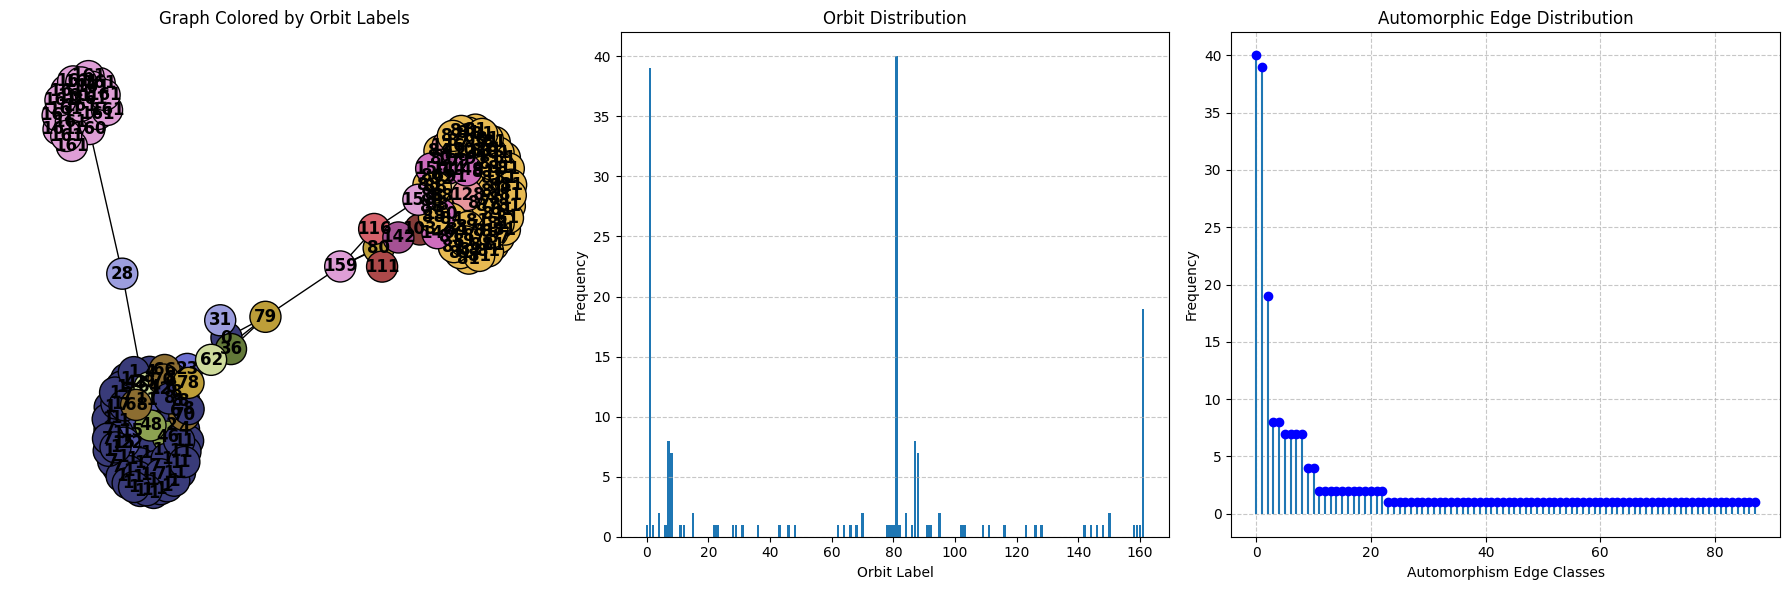

Num nodes: 2708
Num edges: 10556
MaX : 10556


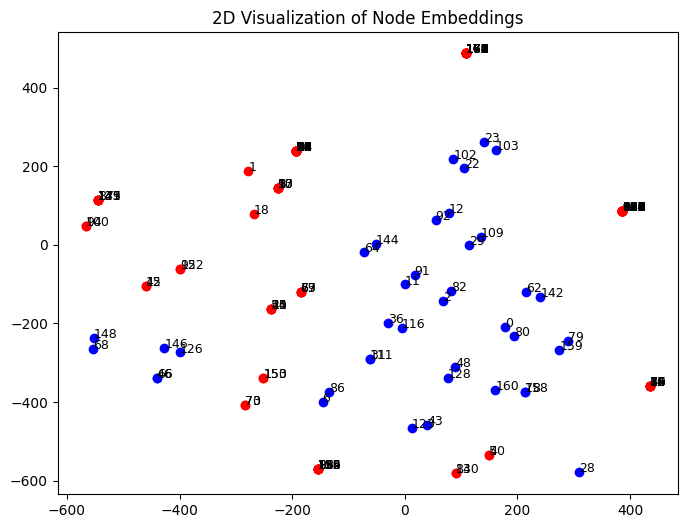

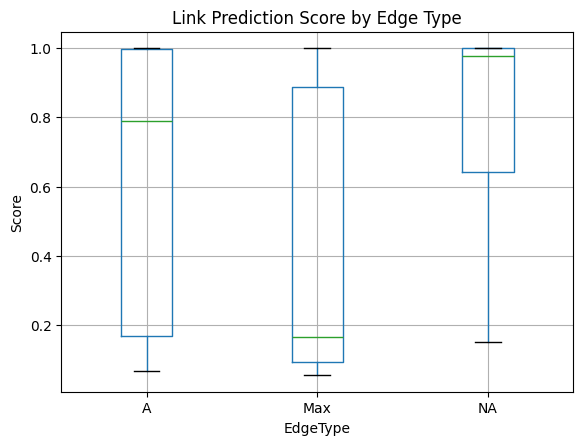

In [15]:
run()